In [1]:
import glob
import os
import re
import argparse
import baltic as bt
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations
from scipy.spatial.distance import squareform #, pdist
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# define genotypes that can co-occur without violating known reassortment patterns
# e.g., EA-2020-C was the parental genotype of the A1, A2, A3, A4, and A5 introductions
# so these genotypes must be allowed to co-occur, as there is no reassortment event separating them
allowed_groups = [
    ['EA-2020-C', 'EA-2020-C (A1)', 'EA-2020-C (A2)', 'EA-2020-C (A3)', 'EA-2020-C (A5)', 'A1', 'A2', 'A3', 'A4', 'A5'],
    ['EA-2021-I', 'EA-2021-I (A6)', 'A6']
] # list of lists of strings

# define ambiguous (unknown) genotype annotation(s)
ambiguous = [
    '?'
] # list of strings

def get_treesort_trees(directory, min_rep, max_rep):
    treesort_trees = sorted(
        glob.glob(
            os.path.join(directory, f'[{min_rep}-{max_rep}]', 'treesort/ha_treesort.tre')
        )
    )
    
    return treesort_trees

def get_metadata(directory, min_rep, max_rep):
    metadata_files = sorted(
        glob.glob(
            os.path.join(directory, f'[{min_rep}-{max_rep}]', 'data/metadata_dates.tsv')
        )
    )

    return metadata_files[0]

def bt_loadTreesortNexus(nexus, newick = None, rerun = False, verbose = False):
    ''' 
    this function preps the treesort output to be readable by baltic.
    nexus: input tree = treesort annotated tree (.tre)
    newick: output tree = baltic-readable tree (.nwk)
    
    1. converts nexus format to nwk
    2. replaces commas with "-" (where the reassorted segments are inferred)
    3. remove the single quotation marks around TS_NODE_####
    4. replaces ? with _ (where there is an undetermined reassortment event)   
    '''
    if newick == None:
        newick = nexus.replace('.tre', '-bt_nwk.nwk')

    # if the newick file hasn't already been generated, or if the 'rerun' flag is True
    if not os.path.exists(newick) or rerun:
        with open(nexus, 'r') as file:
            nexus = file.read()
                
        start_idx = nexus.find('(')
        modified = nexus[start_idx:]
        
        end_idx = modified.find('END;')
        modified = modified[:end_idx]
        	
        # removing commas between segments
        modified = re.sub(r'&rea="([^"]+)"', lambda match: f'&rea="{match.group(1).replace(",", "-")}"', modified)
        
        # removing quotation marks around node names
        modified = re.sub(r"'(TS_NODE_\d+)'", r'\1', modified)
        
        # replacing ? with _ so baltic can read it in
        modified = modified.replace('?', '_')
        
        with open(newick, "w") as output_file:
        	output_file.write(modified.strip())
            
    elif verbose:
        print(f'newick {newick} already exists')

    return bt.loadNewick(newick)

def get_name(k):
    '''
    simple function to return the name of a node or leaf in a baltic tree,
    without prior knowledge of the object type
    '''
    return k.traits.get('label') or k.name

def traverse(k, last_rea_node = None, cluster_dict = None):
    if cluster_dict == None:
        cluster_dict = defaultdict(list)
    last_rea_node = last_rea_node or k
    if k.is_node():
        if k.traits['is_reassorted']:
            last_rea_node = k
        for c in k.children:
            traverse(c, last_rea_node, cluster_dict)
    else:
        if not k.traits['is_reassorted']:
            cluster_dict[last_rea_node].append(k)
        else:
            cluster_dict[k].append(k)

    return cluster_dict

def get_clusters(tree):
    '''
    parse through a treesort-annotated baltic tree and return df with groups of non-reassorting strains.

    to do so, identify all strains that descend from a common reassortment event,
    but that do not have additional reassortment events separating them.

    resultant df will include:
    1. 'cluster' = cluster number
    2. 'bt_node' = the baltic tree node with the cluster-defining inferred reassortment event
    3. 'bt_leaves' = a list of the baltic tree leaves of the cluster
    4. 'node' = the name of the node with the cluster-defining inferred reassortment event
    5. 'leaves' = a list of the names of leaves of the cluster
    '''
    # bt.node:[bt.leaves]
    cluster_dict = traverse(tree.root)
    # TS_NODE:[strain_names]
    cluster_dict_names = {get_name(k):[get_name(vv) for vv in v] for k,v in cluster_dict.items()}
    
    data = []
    
    for i, (node, leaves) in enumerate(cluster_dict.items(), 1):
        cluster = f'cluster{i}'
        node_name = get_name(node)
        leaves_names = [get_name(l) for l in leaves]
    
        data.append({
            'cluster':cluster,
            'bt_node':node,
            'bt_leaves':leaves,
            'node':node_name,
            'leaves':leaves_names
        })
    
    cluster_df = pd.DataFrame(data)
    
    cluster_df['n_leaves'] = cluster_df['leaves'].apply(lambda x:len(x))

    return cluster_df

def get_cooccurences(cluster_dfs, verbose=False):
    all_strains = set()
    for df in cluster_dfs:
        for cluster in df['leaves']:
            all_strains.update(cluster)
    
    all_strains = sorted(list(all_strains))
    strain_to_idx = {strain: idx for idx, strain in enumerate(all_strains)}
    n_strains = len(all_strains)
    
    if verbose:
        print(f'Total unique strains: {n_strains}')
    
    # build co-occurrence matrix for all strains
    if verbose:
        print('Building strain co-occurrence matrix...')
    strain_cooccurrence = np.zeros((n_strains, n_strains))
    
    for df in cluster_dfs:
        for cluster in df['leaves']:
            cluster_set = set(cluster)
            # mark all pairs within this cluster as co-occurring
            for strain1, strain2 in combinations(cluster_set, 2):
                i, j = strain_to_idx[strain1], strain_to_idx[strain2]
                strain_cooccurrence[i, j] += 1
                strain_cooccurrence[j, i] += 1
    
    n_replicates = len(cluster_dfs)

    strain_cooccurrence_normalized = strain_cooccurrence / n_replicates

    return strain_cooccurrence_normalized, all_strains


def generate_linkage_matrix(strain_cooccurrence_normalized, verbose=False):
    '''
    generate an average linkage matrix from a co-clustering frequency matrix
    '''
    
    # convert to distance
    if verbose:
        print("converting co-clustering matrix to distance matrix...")
    distance_matrix = 1 - strain_cooccurrence_normalized
    
    # then to condensed form
    if verbose:
        print("converting to condensed form...")
    condensed_distances = squareform(distance_matrix, checks=False)

    # calculate the average linkage
    if verbose:
        print("computing Average linkage...")
    Z_average = linkage(condensed_distances, method='average')

    return Z_average

def is_coherent_cluster(cluster, allowed_groups = allowed_groups, ambiguous = ambiguous):
    coherent = False
    genotypes = set(g_mapping.get(s, '?') for s in cluster)
    for amb in ambiguous:
        genotypes.discard(amb)
    if len(genotypes) <= 1:
        coherent = True
    else:
        for a_g in allowed_groups:
            if all(g in a_g for g in genotypes):
                coherent = True
    return coherent

def cut_dendrogram_strains(Z, strain_list, cutoff_distance):
    '''
    cut the dendrogram at a given cutoff distance, then return merged strain clusters.
    '''
    strain_assignments = fcluster(Z, cutoff_distance, criterion='distance')
    
    clusters = {}
    for strain_idx, cluster_id in enumerate(strain_assignments):
        if cluster_id not in clusters:
            clusters[cluster_id] = []
        clusters[cluster_id].append(strain_list[strain_idx])
    
    merged_clusters = [sorted(clusters[k]) for k in sorted(clusters.keys())]
    return merged_clusters, len(clusters)

def evaluate_cutoffs_strains(Z, strain_list, coclustering_matrix, genotype_data,
                             cooccurrence_thresholds=[1, 10, 25, 50, 75, 90, 99],
                             strain_col='strain', genotype_col='genotype', n_configs=100,
                             verbose=False):
    '''
    evaluate strain clustering quality at multiple co-occurrence thresholds.
    
    thresholds are based on a replicate cutoff:
        e.g., threshold=50 means "only merge strains that co-occurred in at least half of the replicates"
        formula: cutoff_distance = 1 - (threshold / 100)
    '''
    results = {}
    
    for threshold in cooccurrence_thresholds:
        cutoff_distance = 1 - (threshold / 100)

        if verbose:
            print(f"\nEvaluating co-occurrence threshold at ≥{threshold}% (distance cutoff={cutoff_distance:.4f})...")
            print(f"  (Only merge strains that co-clustered in at least {threshold}% of {n_configs} configs)")
        
        merged_clusters, n_merged = cut_dendrogram_strains(Z, strain_list, cutoff_distance)

        if verbose:
            print(f"  Resulting strain clusters: {n_merged}")
        
        # Validate
        n_incoherent = 0
        n_total = 0
        for cluster in merged_clusters:
            if len(cluster) > 1:
                if not is_coherent_cluster(cluster, allowed_groups, ambiguous):
                    n_incoherent += 1
                    
                    if verbose:
                        print(len(cluster), set(g_mapping.get(s) for s in cluster))
                    
                n_total += 1

        violation_rate = n_incoherent/n_total

        if verbose:
            print(f"  Violation rate: {round(violation_rate*100,1)}%")
        
        
        results[threshold] = {
            'cutoff_distance': cutoff_distance,
            'merged_clusters': merged_clusters,
            'n_resulting_clusters': n_merged,
            'violation_rate': violation_rate,
            'n_incoherent':n_incoherent
        }
    
    return results

def plot_violation_counts(results, savefig=False):
    '''
    plot violation rates and cluster counts across cutoffs.
    '''
    cutoffs = sorted(results.keys())
    n_incoherents = [results[c]['n_incoherent'] for c in cutoffs]
    n_clusters = [results[c]['n_resulting_clusters'] for c in cutoffs]

    # set up figure with 2 subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # plot 1: Violation rate
    ax1.plot(cutoffs, n_clusters, 's-', markersize=10, linewidth=2, color='orange')
    ax1.set_xlabel('Co-occurrence (similarity) threshold')
    ax1.set_ylabel('Number of resulting reassortant clusters')
    ax1.set_title('Cluster Count by Threshold')
    ax1.set_ylim(0, max(n_clusters)+50)
    ax1.grid(alpha=0.3)
    
    # plot 2: Number of clusters
    ax2.plot(cutoffs, n_incoherents, 'o-', markersize=10, linewidth=2)
    ax2.set_xlabel('Co-occurrence (similarity) threshold')
    ax2.set_ylabel('Number of reassortant clusters with mixed genotypes')
    ax2.set_title('Mixed Genotype Clusters by Threshold')
    ax2.set_ylim(0, max(n_incoherents)+1)
    ax2.grid(alpha=0.3)

    
    plt.tight_layout()
    if savefig:
        plt.savefig(savefig)
    else:
        plt.show()

def analyze_clusters_at_threshold(Z, strain_list, genotype_data, threshold=50, 
                                 strain_col='strain', genotype_col='genoflu', n_configs=100):
    """
    flat cluster at a specific threshold and analyze composition
    
    returns:
    - clusters: list of lists, each is a cluster of strain names
    - cluster_sizes: list of cluster sizes
    - genotype_composition: df with % genotypes per cluster
    """
    cutoff_distance = 1 - (threshold / 100)
    
    # get flat cluster assignments
    strain_assignments = fcluster(Z, cutoff_distance, criterion='distance')
    
    # group strains by cluster
    clusters_dict = {}
    for strain_idx, cluster_id in enumerate(strain_assignments):
        if cluster_id not in clusters_dict:
            clusters_dict[cluster_id] = []
        clusters_dict[cluster_id].append(strain_list[strain_idx])
    
    # convert to sorted list
    clusters = [sorted(clusters_dict[k]) for k in sorted(clusters_dict.keys())]
    cluster_sizes = [len(c) for c in clusters]
    
    # determine genotype composition of each cluster
    strain_to_genotype = dict(zip(genotype_data[strain_col], genotype_data[genotype_col]))
    
    genotype_composition_list = []
    
    for cluster_idx, cluster_strains in enumerate(clusters):
        genotype_counts = {}
        
        for strain in cluster_strains:
            if strain in strain_to_genotype:
                gt = strain_to_genotype[strain]
                if pd.isna(gt):
                    gt = 'Unmapped'
                elif gt == '':
                    gt = 'Blank'
            else:
                gt = 'Unmapped'
            
            genotype_counts[gt] = genotype_counts.get(gt, 0) + 1
        
        # convert counts to percentages
        total = len(cluster_strains)
        genotype_pcts = {gt: (count / total * 100) for gt, count in genotype_counts.items()}
        
        # create row for this cluster
        row = {
            'Cluster_ID': cluster_idx,
            'Cluster_Size': total,
        }
        
        # and add genotype percentages to the row
        for gt, pct in genotype_pcts.items():
            row[f'{gt}_pct'] = round(pct, 2)
            row[f'{gt}_count'] = genotype_counts[gt]
        
        genotype_composition_list.append(row)
    
    genotype_composition = pd.DataFrame(genotype_composition_list)
    
    return clusters, cluster_sizes, genotype_composition

def get_primary_genotype(row):
    # find all columns that end with '_pct'
    pct_cols = [col for col in row.index if col.endswith('_pct')]
    
    # find the column with the maximum value
    max_col = max(pct_cols, key=lambda col: row[col])
    
    # extract genotype name
    genotype = max_col.replace('_pct', '')
    pct = row[max_col]
    
    return f"{genotype} ({pct:.1f}%)"

In [2]:
main_directory = "/Users/jort/coding/h5nx-reassortment-and-risk-assessment/treesort-sameStrains-replicates/10_by_10/beiting_server/10_by_10"

min_rep = 0
max_rep = 9

cluster_dfs = {}

for n_backbone in range(min_rep, max_rep+1):
    for n_other in range(min_rep, max_rep+1):
        treesort_tree = f'{main_directory}/{n_backbone}_{n_other}/treesort/ha_treesort.tre'
        if os.path.exists(treesort_tree):
            tree = bt_loadTreesortNexus(treesort_tree)
            cluster_dfs[f'{n_backbone}_{n_other}'] = get_clusters(tree)

In [3]:
# check the df output for a single replicate
cluster_dfs['0_0']

,cluster,bt_node,bt_leaves,node,leaves,n_leaves
0,cluster1,<baltic.baltic.node object at 0x109df3b10>,"[<baltic.baltic.leaf object at 0x1737d4d70>, <...",TS_NODE_15,[A/chicken/Queretaro/CPA0170823/2023|2023-02-1...,16
1,cluster2,<baltic.baltic.leaf object at 0x1737bbcb0>,[<baltic.baltic.leaf object at 0x1737bbcb0>],A/chicken/Jalisco/CPA0494823/2023|2023-04-05,[A/chicken/Jalisco/CPA0494823/2023|2023-04-05],1
2,cluster3,<baltic.baltic.node object at 0x10a3fbc20>,"[<baltic.baltic.leaf object at 0x109ef6200>, <...",TS_NODE_11098,[A/mallard/Illinois/23039796003original/2023|2...,6
3,cluster4,<baltic.baltic.leaf object at 0x109ef4520>,[<baltic.baltic.leaf object at 0x109ef4520>],A/greenwingedteal/Wisconsin/23037645016origina...,[A/greenwingedteal/Wisconsin/23037645016origin...,1
4,cluster5,<baltic.baltic.leaf object at 0x10a5e5950>,[<baltic.baltic.leaf object at 0x10a5e5950>],A/mallard/Alaska/AK20526/2020|2020-10-22,[A/mallard/Alaska/AK20526/2020|2020-10-22],1
...,...,...,...,...,...,...
720,cluster721,<baltic.baltic.node object at 0x174267d80>,"[<baltic.baltic.leaf object at 0x17427cd70>, <...",TS_NODE_3054,[A/dairycow/HongKong/RGDelNS1p10/2024|2024-05-...,2
721,cluster722,<baltic.baltic.leaf object at 0x17427ce10>,[<baltic.baltic.leaf object at 0x17427ce10>],A/dairycow/Texas/24008749003R/2024|2024-05-27,[A/dairycow/Texas/24008749003R/2024|2024-05-27],1
722,cluster723,<baltic.baltic.leaf object at 0x174153930>,[<baltic.baltic.leaf object at 0x174153930>],A/dairycattle/Texas/24009495007/2024|2024-03-21,[A/dairycattle/Texas/24009495007/2024|2024-03-21],1
723,cluster724,<baltic.baltic.node object at 0x1741ac7e0>,"[<baltic.baltic.leaf object at 0x17419ed50>, <...",TS_NODE_2391,"[A/dairycow/Idaho/24022349001/2024|2024-08-01,...",9


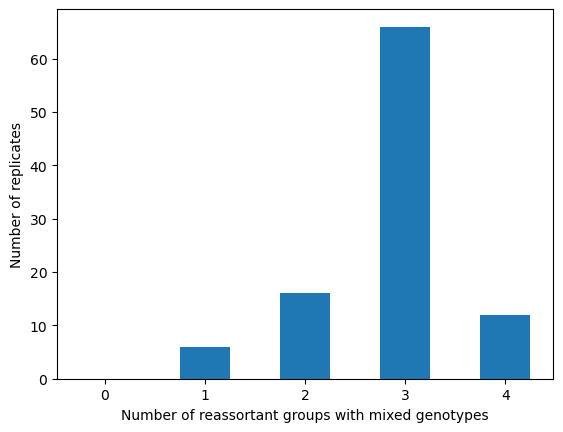

In [4]:
# analysis to check how proportion of 2+ strain clusters that pair incompatible genotypes
DEBUG = False

genotypes = 'ea_na_genotypes_dates.tsv'
g_df = pd.read_csv(genotypes, sep='\t')

g_mapping = dict(zip(g_df['strain'], g_df['EA_NA_genotype']))

all_counts = {}
for rep, df in cluster_dfs.items():
    counts = [0,0] # (coherent, incoherent)
    for cluster in df['leaves']:
        if len(cluster) > 1:
            if is_coherent_cluster(cluster, allowed_groups, ambiguous):
                counts[0] += 1
            else:
                counts[1] += 1
                if DEBUG and rep[0] == rep[-1]:
                    print(rep, set(g_mapping.get(s) for s in cluster), cluster)
    all_counts[rep] = counts

all_pcts = []
for l in all_counts.values():
    all_pcts.append(l[1]/(l[0]+l[1])*100)
    
r_df = pd.DataFrame(all_counts).T

r_df['total_clusters'] = r_df[0]
r_df['incoherent_clusters'] = r_df[1]
r_df['HA_backbone'] = r_df.index.map(lambda x:x[0])
r_df['nonHA_tree_set'] = r_df.index.map(lambda x:x[-1])


# r_df.plot.hist('incoherent_clusters')
ax = r_df['incoherent_clusters'].plot.hist(bins=[0,0.5,1,1.5,2,2.5,3,3.5,4,4.5])
ax.set_xticks([0.25, 1.25, 2.25, 3.25,4.25])
ax.set_xticklabels([0,1,2,3,4])
ax.set_xlabel('Number of reassortant groups with mixed genotypes')
ax.set_ylabel('Number of replicates')
# plt.show()
plt.savefig('numIncoherentGroups-histogram.pdf')

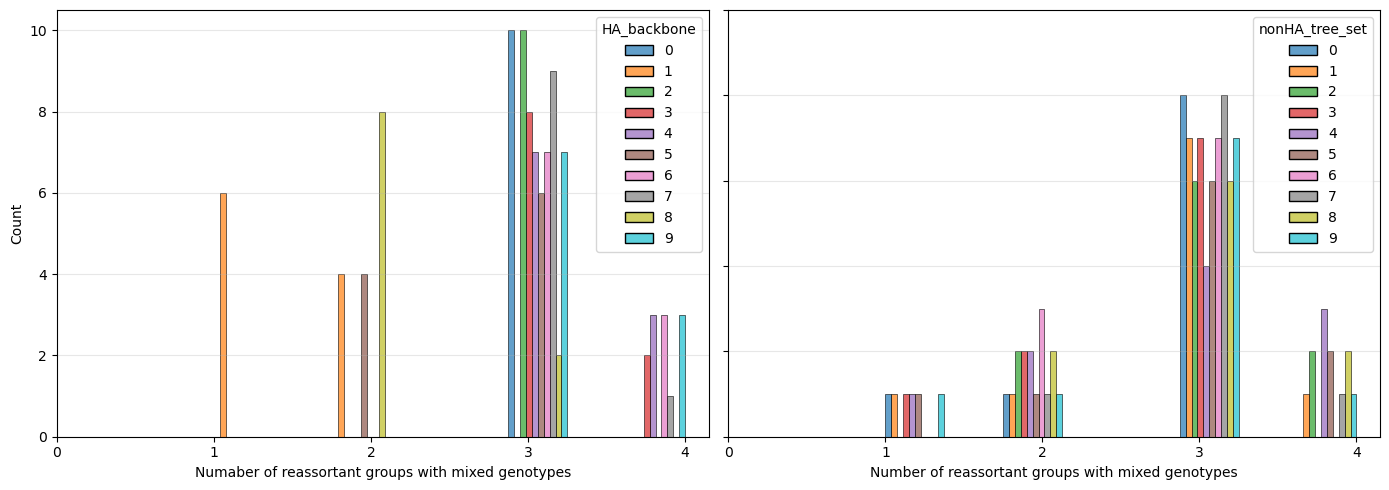

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Get unique values to know how many colors you need
n_ha = r_df['HA_backbone'].nunique()
n_nonha = r_df['nonHA_tree_set'].nunique()

r_df = r_df.replace(0, 0.0001)

# Create palettes with enough colors
# ha_palette = sns.color_palette("husl", n_ha)
# nonha_palette = sns.color_palette("husl", n_nonha)

# Histogram 1: incoherent_clusters colored by HA_backbone
sns.histplot(data=r_df, x='incoherent_clusters', hue='HA_backbone', 
             ax=axes[0], edgecolor='black', alpha=0.7, stat='count',
            multiple='dodge')
axes[0].set_xticks([0, 1, 2, 3, 4])
axes[0].set_xlabel('Numaber of reassortant groups with mixed genotypes')
axes[0].set_ylabel('Count')
# axes[0].set_title('Number of reassortant groups with mixed genotypes')
axes[0].grid(alpha=0.3, axis='y')

# Histogram 2: incoherent_clusters colored by nonHA_tree_set
sns.histplot(data=r_df, x='incoherent_clusters', hue='nonHA_tree_set', 
             ax=axes[1], edgecolor='black', alpha=0.7, stat='count',
             multiple='dodge')
axes[1].set_xticks([0, 1, 2, 3, 4])
axes[1].set_xlabel('Number of reassortant groups with mixed genotypes')
axes[1].set_yticks([0,2,4,6,8,10])
axes[1].set_yticklabels([])
axes[1].set_ylabel(None)
# axes[1].set_title('Numaber of reassortant groups with mixed genotypes')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
# plt.show()
plt.savefig('numIncoherentGroups-byReplicate.pdf')

In [6]:
strain_cooccurrence_normalized, strain_list = get_cooccurences(cluster_dfs.values())
strain_cooccurrence_normalized

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [7]:
Z_average = generate_linkage_matrix(strain_cooccurrence_normalized)
Z_average

array([[0.0000e+00, 1.4800e+02, 0.0000e+00, 2.0000e+00],
       [1.0000e+00, 2.0000e+00, 0.0000e+00, 2.0000e+00],
       [3.0000e+00, 1.1102e+04, 0.0000e+00, 3.0000e+00],
       ...,
       [2.0648e+04, 2.2197e+04, 1.0000e+00, 1.0558e+04],
       [2.1626e+04, 2.2198e+04, 1.0000e+00, 1.1100e+04],
       [1.1100e+04, 2.2199e+04, 1.0000e+00, 1.1101e+04]])

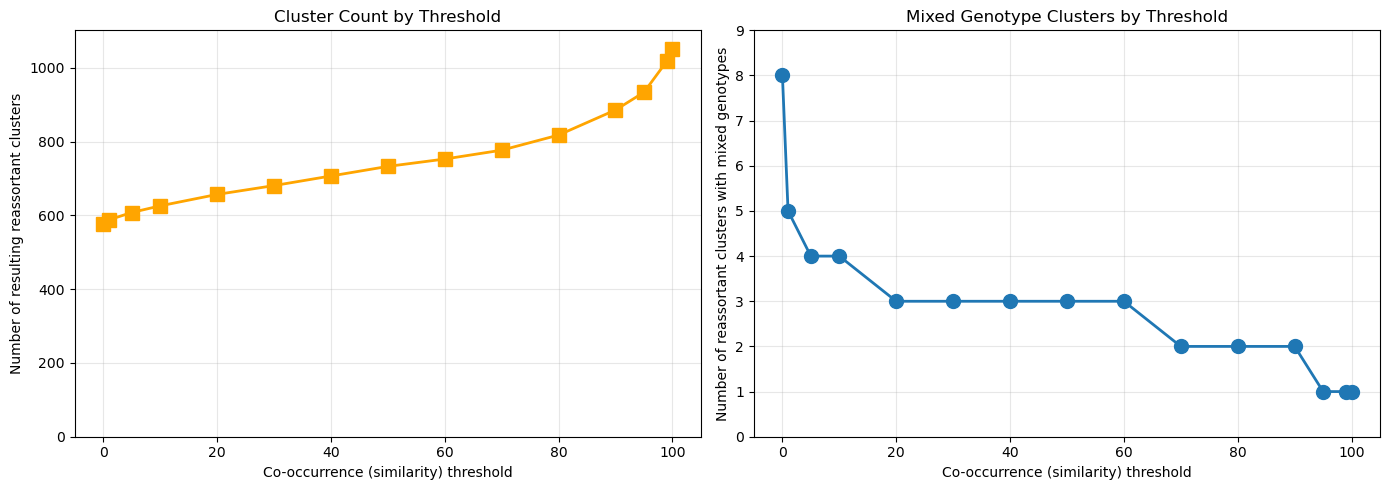

In [8]:
cooccurrence_thresholds = [0.01, 1, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 99, 99.99]

cutoff_results = evaluate_cutoffs_strains(
    Z_average,
    strain_list,
    coclustering_matrix=strain_cooccurrence_normalized,
    genotype_data=g_df,
    cooccurrence_thresholds=cooccurrence_thresholds,
    strain_col='strain',
    genotype_col='EA_NA_genotype'
)

plot_violation_counts(cutoff_results, 'clustersCount-incoherentCount-byCutoffs.pdf')

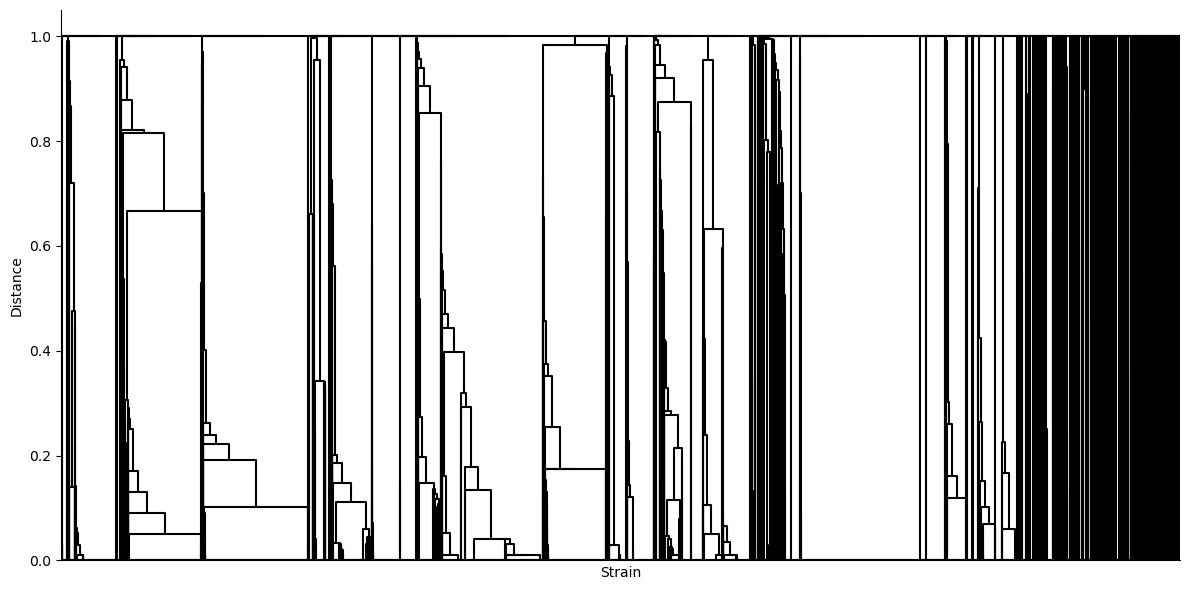

In [9]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

fig, ax = plt.subplots(figsize=(12, 6))

dendrogram(Z_average, ax=ax, no_labels=True, color_threshold=-1, above_threshold_color='black')


ax.set_xlabel('Strain')
ax.set_ylabel('Distance')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
# plt.show()
plt.savefig('dendrogram-allBlack.pdf')

In [10]:
# thresholds to analyze
thresholds = [50, 90, 95]

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import fcluster

# load genotype data
genotype_data = pd.read_csv('ea_na_genotypes.tsv', sep='\t')
genotype_col = 'EA_NA_genotype'

# store results in dicts
all_cluster_dict = {}
all_sizes_dict = {}
all_composition_dict = {}

# analyze each desired threshold
for threshold in thresholds:
    print(f"processing threshold: {threshold}%...")
    
    clusters, cluster_sizes, genotype_composition = analyze_clusters_at_threshold(
        Z_average, strain_list, genotype_data, threshold=threshold,
        strain_col='strain', genotype_col=genotype_col
    )

    all_cluster_dict[threshold] = clusters
    all_sizes_dict[threshold] = cluster_sizes
    all_composition_dict[threshold] = genotype_composition
    
    # Save composition to CSV
    csv_filename = f'cluster_composition_{threshold}percent.csv'
    genotype_composition.to_csv(csv_filename, index=False)
    print(f"   saved to: {csv_filename}")
    print()

processing threshold: 50%...
   saved to: cluster_composition_50percent.csv

processing threshold: 90%...
   saved to: cluster_composition_90percent.csv

processing threshold: 95%...
   saved to: cluster_composition_95percent.csv



In [13]:
# inspect cluster_composition df for last threshold
genotype_composition

,Cluster_ID,Cluster_Size,EA-2022-CH_pct,EA-2022-CH_count,EA-2021-AB_pct,EA-2021-AB_count,?_pct,?_count,EA-2021-P_pct,EA-2021-P_count,...,Minor17_pct,Minor17_count,Minor104_pct,Minor104_count,Minor79_pct,Minor79_count,EA-2024-EA_pct,EA-2024-EA_count,Minor63_pct,Minor63_count
0,0,2,100.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,55,100.0,55.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,11,NaN,NaN,90.91,10.0,9.09,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1,NaN,NaN,100.00,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1,NaN,NaN,100.00,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
929,929,1,NaN,NaN,NaN,NaN,100.00,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
930,930,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
931,931,1,NaN,NaN,NaN,NaN,100.00,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
932,932,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


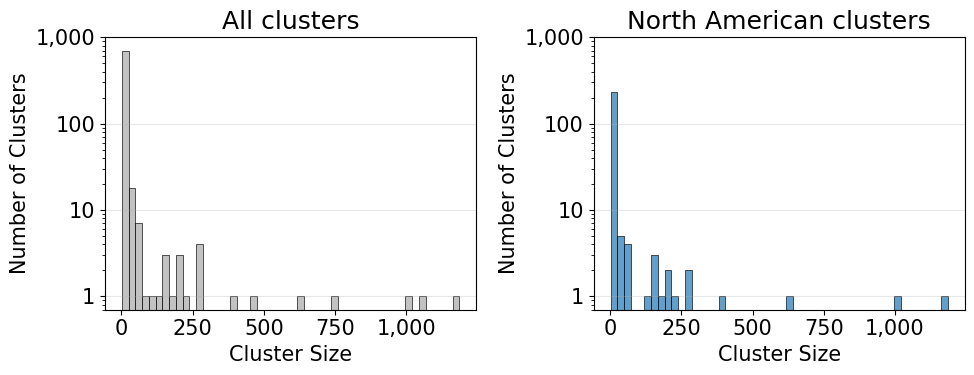

Summary statistics for all clusters at the 50% threshold:
Total clusters: 733
n = 1: 437 (59.6%)
n ≤ 10: 656 (89.5%)
n ≥ 100: 21 (2.86%)
n ≥ 200: 13 (1.77%)
n ≥ 400: 6 (0.82%)

Summary statistics for North American clusters at the 50% threshold:
Total clusters (including mixed geography): 255
N.Am. exclusive: 240 (94.1%)
n = 1: 150 (58.8%)
n ≤ 10: 221 (86.7%)
n ≥ 100: 14 (5.49%)
n ≥ 200: 8 (3.14%)
n ≥ 400: 3 (1.18%)


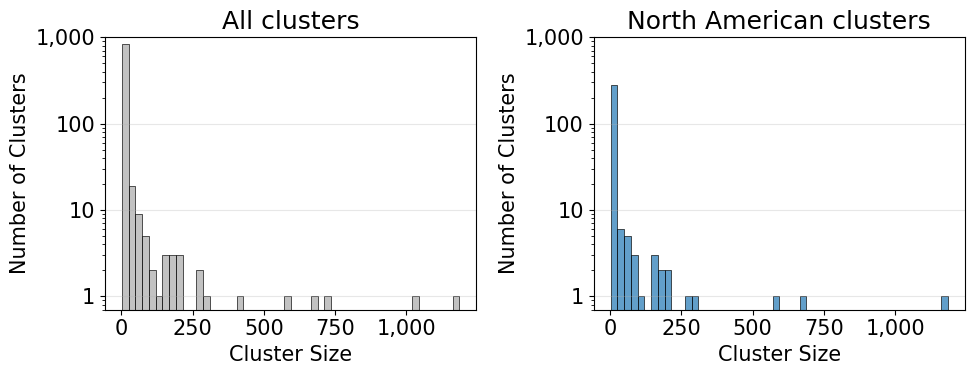

Summary statistics for all clusters at the 90% threshold:
Total clusters: 886
n = 1: 534 (60.3%)
n ≤ 10: 795 (89.7%)
n ≥ 100: 21 (2.37%)
n ≥ 200: 10 (1.13%)
n ≥ 400: 6 (0.68%)

Summary statistics for North American clusters at the 90% threshold:
Total clusters (including mixed geography): 306
N.Am. exclusive: 287 (93.8%)
n = 1: 179 (58.5%)
n ≤ 10: 263 (85.9%)
n ≥ 100: 13 (4.25%)
n ≥ 200: 6 (1.96%)
n ≥ 400: 3 (0.98%)


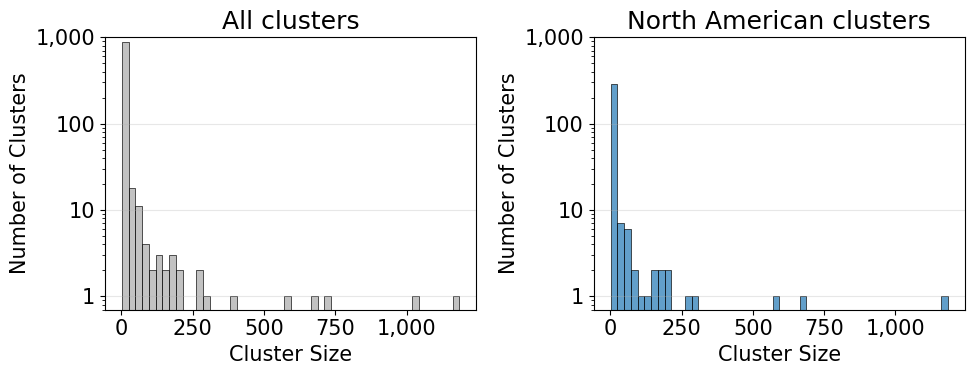

Summary statistics for all clusters at the 95% threshold:
Total clusters: 934
n = 1: 566 (60.6%)
n ≤ 10: 839 (89.8%)
n ≥ 100: 21 (2.25%)
n ≥ 200: 10 (1.07%)
n ≥ 400: 5 (0.54%)

Summary statistics for North American clusters at the 95% threshold:
Total clusters (including mixed geography): 317
N.Am. exclusive: 298 (94.0%)
n = 1: 187 (59.0%)
n ≤ 10: 272 (85.8%)
n ≥ 100: 13 (4.1%)
n ≥ 200: 6 (1.89%)
n ≥ 400: 3 (0.95%)


In [14]:
# load metadata and map regions to strains
m_df = pd.read_table('metadata_dates.tsv')
region_mapping = dict(zip(m_df['strain'], m_df['region']))

for threshold in thresholds:
    clusters = all_cluster_dict[threshold]
    
    n_am = []
    n_am_mixed_geography = []
    sizes = []
    
    for cluster in clusters:
        regions = set([region_mapping.get(c, region_mapping.get(c.replace('?', '_'))) for c in cluster])
        if 'North America' in regions:
            n_am.append(True)
            if len(regions) > 1:
                n_am_mixed_geography.append(True)
            else:
                n_am_mixed_geography.append(False)
        else:
            n_am.append(False)
            n_am_mixed_geography.append(False)
        sizes.append(len(cluster))
    
    df1 = pd.DataFrame({'n_am':n_am, 'n_am_mixed_geography':n_am_mixed_geography, 'size':sizes})
    
    plt_dfs = [df1, df1.query("n_am")]
    titles = [
        'All clusters',
        'North American clusters'
    ]
    colors = [
        'darkgrey',
        'tab:blue'
    ]
    
    plt.rcParams.update({'font.size': plt.rcParamsDefault['font.size'] * 1.5})
    
    fig, axes = plt.subplots(1, 2, figsize=(10,4))
    
    for ax, plt_df, title, color in zip(axes, plt_dfs, titles, colors):
        # Use seaborn histplot with hue
        sns.histplot(data=plt_df, x='size', color=color,
                     bins=50, ax=ax,
                     edgecolor='black', alpha=0.7)
        
        ax.set_xlabel('Cluster Size')
        ax.set_xticks([0, 250, 500, 750, 1000])
        ax.set_xticklabels([0, 250, 500, 750, '1,000'])
        ax.set_ylabel('Number of Clusters')
        ax.set_yscale('log')
        ax.set_ylim(0.7, 1000)
        ax.set_yticks([1, 10, 100, 1000])
        ax.set_yticklabels([1, 10, 100, '1,000'])
        ax.set_title(title)
        ax.grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(f'{threshold}percent_threshold-all_and_nAm_clusters.pdf')
    plt.show()
    
    cluster_df = plt_dfs[0]
    print(f'Summary statistics for all clusters at the {threshold}% threshold:')
    n_total = len(cluster_df)
    n_singletons = len(cluster_df.query("size == 1"))
    n_10_or_less = len(cluster_df.query("size <= 10"))
    n_100_or_more = len(cluster_df.query("size >= 100"))
    n_200_or_more = len(cluster_df.query("size >= 200"))
    n_400_or_more = len(cluster_df.query("size >= 400"))
    print(f'Total clusters: {n_total}')
    print(f'n = 1: {n_singletons} ({round(n_singletons/n_total*100, 1)}%)')
    print(f'n ≤ 10: {n_10_or_less} ({round(n_10_or_less/n_total*100, 1)}%)')
    print(f'n ≥ 100: {n_100_or_more} ({round(n_100_or_more/n_total*100, 2)}%)')
    print(f'n ≥ 200: {n_200_or_more} ({round(n_200_or_more/n_total*100, 2)}%)')
    print(f'n ≥ 400: {n_400_or_more} ({round(n_400_or_more/n_total*100, 2)}%)')
    print()
    
    cluster_df = plt_dfs[1]
    print(f'Summary statistics for North American clusters at the {threshold}% threshold:')
    n_total = len(cluster_df)
    n_n_am_only = n_total - len(cluster_df.query("n_am_mixed_geography"))
    n_singletons = len(cluster_df.query("size == 1"))
    n_10_or_less = len(cluster_df.query("size <= 10"))
    n_100_or_more = len(cluster_df.query("size >= 100"))
    n_200_or_more = len(cluster_df.query("size >= 200"))
    n_400_or_more = len(cluster_df.query("size >= 400"))
    print(f'Total clusters (including mixed geography): {n_total}')
    print(f'N.Am. exclusive: {n_n_am_only} ({round(n_n_am_only/n_total*100, 1)}%)')
    print(f'n = 1: {n_singletons} ({round(n_singletons/n_total*100, 1)}%)')
    print(f'n ≤ 10: {n_10_or_less} ({round(n_10_or_less/n_total*100, 1)}%)')
    print(f'n ≥ 100: {n_100_or_more} ({round(n_100_or_more/n_total*100, 2)}%)')
    print(f'n ≥ 200: {n_200_or_more} ({round(n_200_or_more/n_total*100, 2)}%)')
    print(f'n ≥ 400: {n_400_or_more} ({round(n_400_or_more/n_total*100, 2)}%)')

In [17]:
for threshold in thresholds:
    df = pd.read_csv(f'cluster_composition_{threshold}percent.csv')

    df = df.fillna(0)
    
    df = df.sort_values(by='Cluster_Size', ascending=False).query("Cluster_Size >= 100")
    
    df['Primary_Genotype'] = df.apply(get_primary_genotype, axis=1)
    
    cols = df.columns.tolist()
    cols.insert(2, cols.pop(cols.index('Primary_Genotype')))
    df = df[cols]
    
    print(f'Clusters of 100+ strains at the {threshold}% threshold:')
    display(df)
    df.to_csv(f'largeClusters_genotype_composition_{threshold}percent.csv')
    print()

Clusters of 100+ strains at the 50% threshold:


,Cluster_ID,Cluster_Size,Primary_Genotype,EA-2022-CH_pct,EA-2022-CH_count,EA-2021-AB_pct,EA-2021-AB_count,?_pct,?_count,EA-2021-P_pct,...,Minor17_pct,Minor17_count,Minor104_pct,Minor104_count,Minor79_pct,Minor79_count,EA-2024-EA_pct,EA-2024-EA_count,Minor63_pct,Minor63_count
149,149,1187,B3.13 (98.0%),0.0,0.0,0.0,0.0,2.02,24.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21,21,1049,EA-2022-BB (99.0%),0.0,0.0,0.0,0.0,0.95,10.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
53,53,1001,EA-2020-C (39.3%),0.0,0.0,0.0,0.0,0.40,4.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14,14,757,EA-2024-DI (99.1%),0.0,0.0,0.0,0.0,0.92,7.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
62,62,631,B3.2 (99.4%),0.0,0.0,0.0,0.0,0.63,4.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,467,EA-2021-AB (97.0%),0.0,0.0,97.0,453.0,3.00,14.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40,40,393,B3.6 (100.0%),0.0,0.0,0.0,0.0,0.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
44,44,277,D1.1 (100.0%),0.0,0.0,0.0,0.0,0.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
90,90,273,EA-2020-A (95.2%),0.0,0.0,0.0,0.0,4.76,13.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
102,102,272,EA-2020-A (98.9%),0.0,0.0,0.0,0.0,1.10,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Clusters of 100+ strains at the 90% threshold:


,Cluster_ID,Cluster_Size,Primary_Genotype,EA-2022-CH_pct,EA-2022-CH_count,EA-2021-AB_pct,EA-2021-AB_count,?_pct,?_count,EA-2021-P_pct,...,Minor17_pct,Minor17_count,Minor104_pct,Minor104_count,Minor79_pct,Minor79_count,EA-2024-EA_pct,EA-2024-EA_count,Minor63_pct,Minor63_count
261,261,1186,B3.13 (98.0%),0.0,0.0,0.00,0.0,2.02,24.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38,38,1041,EA-2022-BB (99.0%),0.0,0.0,0.00,0.0,0.96,10.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
27,27,722,EA-2024-DI (99.2%),0.0,0.0,0.00,0.0,0.83,6.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
108,108,680,EA-2020-C (A3) (38.7%),0.0,0.0,0.00,0.0,0.44,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
124,124,591,B3.2 (99.3%),0.0,0.0,0.00,0.0,0.68,4.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,7,404,EA-2021-AB (97.0%),0.0,0.0,97.03,392.0,2.97,12.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75,75,300,B3.6 (100.0%),0.0,0.0,0.00,0.0,0.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
81,81,275,D1.1 (100.0%),0.0,0.0,0.00,0.0,0.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
190,190,272,EA-2020-A (98.9%),0.0,0.0,0.00,0.0,1.10,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
147,147,204,B4.1 (100.0%),0.0,0.0,0.00,0.0,0.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Clusters of 100+ strains at the 95% threshold:


,Cluster_ID,Cluster_Size,Primary_Genotype,EA-2022-CH_pct,EA-2022-CH_count,EA-2021-AB_pct,EA-2021-AB_count,?_pct,?_count,EA-2021-P_pct,...,Minor17_pct,Minor17_count,Minor104_pct,Minor104_count,Minor79_pct,Minor79_count,EA-2024-EA_pct,EA-2024-EA_count,Minor63_pct,Minor63_count
297,297,1185,B3.13 (98.0%),0.0,0.0,0.00,0.0,2.03,24.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47,47,1027,EA-2022-BB (99.0%),0.0,0.0,0.00,0.0,0.97,10.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
33,33,721,EA-2024-DI (99.2%),0.0,0.0,0.00,0.0,0.83,6.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
131,131,680,EA-2020-C (A3) (38.7%),0.0,0.0,0.00,0.0,0.44,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
148,148,589,B3.2 (99.3%),0.0,0.0,0.00,0.0,0.68,4.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,9,398,EA-2021-AB (97.0%),0.0,0.0,96.98,386.0,3.02,12.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
85,85,300,B3.6 (100.0%),0.0,0.0,0.00,0.0,0.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
93,93,272,D1.1 (100.0%),0.0,0.0,0.00,0.0,0.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
221,221,264,EA-2020-A (98.9%),0.0,0.0,0.00,0.0,1.14,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
173,173,204,B4.1 (100.0%),0.0,0.0,0.00,0.0,0.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
